# PatchScopes Multi-Token Word Reconstruction - LLaMA-2-7B

### Requirements met in this experiment

| Requirement |  Implementation |
|-------------|----------------|
| Model: LLaMA-2-7B | checked |
| Sample: 200-500 words | 200 words |
| Dataset: WikiText-103 | checked |
| Seeds: 2-3 with mean ± 95% CI | 2 seeds |
| Alphabetic-only filtering | Strict filter |
| Prompt: 'English: X, X' | checked |
| Metric: Success@1 | checked |
| True PatchScopes decoding | Tokens2Words library |



## Part 1: Setup and Installation

In [1]:
# Install dependencies
!pip install -q datasets transformers accelerate scipy scikit-learn matplotlib pandas tqdm
!pip install -q bitsandbytes

# Clone Tokens2Words repository
!git clone https://github.com/schwartz-lab-NLP/Tokens2Words.git

import sys
sys.path.insert(0, 'Tokens2Words/src')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 38.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.5 MB/s eta 0:00:0000:0100:01
ERROR: pip's de

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer
import random
import re
import os
from tqdm import tqdm
from scipy import stats
import gc

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.8 GB


## Part 2: Configuration

In [17]:
# CONFIGURATION

# LLaMA-2-7B model
MODEL_NAME = "meta-llama/Llama-2-7b-hf"

# 200 words, 2 seeds for more robustness
NUM_WORDS = 200
SEEDS = [42, 123]

# Strict alphabetic filtering
MIN_WORD_LENGTH = 4
MIN_TOKENS = 2
MAX_TOKENS = 6

# PatchScopes prompt
PATCHSCOPES_PROMPT = "English: X, X"

OUTPUT_DIR = "patchscopes_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration:")
print(f"  Model: {MODEL_NAME}")
print(f"  Words: {NUM_WORDS}")
print(f"  Seeds: {SEEDS}")
print(f"  Prompt: '{PATCHSCOPES_PROMPT}'")

Configuration:
  Model: meta-llama/Llama-2-7b-hf
  Words: 200
  Seeds: [42, 123]
  Prompt: 'English: X, X'


## Part 3: HuggingFace Authentication

In [4]:
from huggingface_hub import login
login()  # Enter your token when prompted

## Part 4: Strict Word Filtering 

In [16]:
def is_valid_word_strict(word):
    """
    This filter accepts ONLY:
    - Lowercase alphabetic words (common English words)
    - ASCII characters only
    - Minimum 4 characters
    
    Rejects:
    - Numbers, numerals, punctuation
    - Acronyms
    - Proper nouns
    - Mixed case (FarmVille)
    - Non-ASCII (café)
    """
    # Length check
    if len(word) < MIN_WORD_LENGTH:
        return False
    
    # Must be purely alphabetic 
    if not word.isalpha():
        return False
    
    # Must be ASCII only
    if not word.isascii():
        return False
    
    # Must be all lowercase (to exclude proper nouns)
    if not word.islower():
        return False
    
    return True


# Test the filter
test_cases = [
    ("extinguishers", True, "common word"),
    ("paramedic", True, "common word"),
    ("0", False, "numeral"),
    ("123abc", False, "contains numbers"),
    ("KSTP", False, "acronym"),
    ("Burma", False, "proper noun"),
    ("FarmVille", False, "mixed case"),
    ("café", False, "non-ASCII"),
]

print("Strict Filter Test:")
print("-" * 60)
for word, expected, reason in test_cases:
    result = is_valid_word_strict(word)
    status = "GOOD" if result == expected else "FAIL"
    print(f"{status} '{word}' -> {result} ({reason})")

Strict Filter Test:
------------------------------------------------------------
GOOD 'extinguishers' -> True (common word)
GOOD 'paramedic' -> True (common word)
GOOD '0' -> False (numeral)
GOOD '123abc' -> False (contains numbers)
GOOD 'KSTP' -> False (acronym)
GOOD 'Burma' -> False (proper noun)
GOOD 'FarmVille' -> False (mixed case)
GOOD 'café' -> False (non-ASCII)


## Part 5: Extract Multi-Token Words from WikiText-103

In [6]:
# Load dataset (Future Step 2: WikiText-103)
print("Loading WikiText-103...")
dataset = load_dataset("wikitext", "wikitext-103-v1", split="train")
print(f"Loaded {len(dataset)} examples")

# Load tokenizer
print(f"\nLoading tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocab size: {tokenizer.vocab_size}")

Loading WikiText-103...


README.md: 0.00B [00:00, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Vocab size: 32000


In [7]:
def extract_strict_multi_token_words(dataset, tokenizer, num_words, seed):
    """
    Extract multi-token words with strict filtering.
    """
    random.seed(seed)
    np.random.seed(seed)
    
    # Collect all text
    print("Extracting text from dataset...")
    all_text = " ".join([ex['text'] for ex in dataset if ex['text'].strip()])
    
    # Extract ONLY lowercase words
    # Excluding numerals
    words = re.findall(r'\b[a-z]{4,}\b', all_text)
    unique_words = list(set(words))
    print(f"Unique lowercase words (4+ chars): {len(unique_words)}")
    
    # Find multi-token words
    multi_token_words = []
    
    for word in tqdm(unique_words, desc="Finding multi-token words"):
        if not is_valid_word_strict(word):
            continue
        
        tokens = tokenizer.encode(word, add_special_tokens=False)
        
        # Must be multi-token (2-6 tokens)
        if len(tokens) < MIN_TOKENS or len(tokens) > MAX_TOKENS:
            continue
        
        decoded = tokenizer.decode(tokens, skip_special_tokens=True).strip()
        if decoded.lower() != word.lower():
            continue
        
        multi_token_words.append({
            'word': word,
            'num_tokens': len(tokens)
        })
    
    print(f"\nFound {len(multi_token_words)} valid multi-token words")
    
    # Sample
    random.shuffle(multi_token_words)
    selected = multi_token_words[:num_words]
    
    # Show distribution
    from collections import Counter
    token_dist = Counter([w['num_tokens'] for w in selected])
    print("\nToken distribution:")
    for n in sorted(token_dist.keys()):
        print(f"  {n} tokens: {token_dist[n]} words")
    
    return selected


# Extract words
word_data = extract_strict_multi_token_words(dataset, tokenizer, NUM_WORDS, seed=SEEDS[0])
WORD_LIST = [w['word'] for w in word_data]

print(f"\nSelected {len(WORD_LIST)} words")
print("\nSample words:")
for w in WORD_LIST[:20]:
    print(f"  {w}")

Extracting text from dataset...
Unique lowercase words (4+ chars): 82693


Finding multi-token words: 100%|██████████| 82693/82693 [00:05<00:00, 15128.69it/s]



Found 76910 valid multi-token words

Token distribution:
  2 tokens: 91 words
  3 tokens: 77 words
  4 tokens: 27 words
  5 tokens: 5 words

Selected 200 words

Sample words:
  vetch
  landmasses
  chromatographic
  colemanite
  overripe
  negligible
  encomendero
  incomparable
  belles
  boarded
  theming
  roadwheels
  campsites
  extravagances
  caprellid
  lactones
  perimeters
  imitated
  gesturing
  pillowcases


In [8]:
# Save word list for Tokens2Words
word_list_path = f"{OUTPUT_DIR}/word_list.txt"
with open(word_list_path, 'w') as f:
    f.write('\n'.join(WORD_LIST))
print(f"Saved word list to: {word_list_path}")

# Also save as CSV with metadata
word_df = pd.DataFrame(word_data)
word_df.to_csv(f"{OUTPUT_DIR}/word_list_metadata.csv", index=False)
print(f"Saved metadata to: {OUTPUT_DIR}/word_list_metadata.csv")

Saved word list to: patchscopes_results/word_list.txt
Saved metadata to: patchscopes_results/word_list_metadata.csv


## Part 6: Run PatchScopes via Tokens2Words

This uses the **PatchScopes implementation** from the Tokens2Words library using the method:
> "PatchScopes Decoding: Hidden states were fed back through the decoder to predict the most probable word using the prompt 'English: X, X'."

In [9]:
# Run Tokens2Words PatchScopes for each seed
import subprocess

# Experiment name base for Tokens2Words outputs
EXP_NAME_BASE = "llama2-7b_wiki103_strict"
import subprocess

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"Running PatchScopes with seed {seed}")
    print(f"{'='*60}")
    
    seed_dir = f"{OUTPUT_DIR}/seed_{seed}"
    os.makedirs(seed_dir, exist_ok=True)
    
    exp_name = f"{EXP_NAME_BASE}_seed{seed}"
    
    # Build command
    cmd = f"""
    cd Tokens2Words && \
    PYTHONPATH=$PYTHONPATH:./src python -m tokens2words.run_patchscopes \
        --exp_name {exp_name} \
        --model_name {MODEL_NAME} \
        --seed {seed} \
        --words_list ../{word_list_path} \
        --words_list_delimiter "newline" \
        --patchscopes_prompt "{PATCHSCOPES_PROMPT}" \
        --patchscopes_prompt_target "X" \
        --patchscopes_max_words {NUM_WORDS} \
        --patchscopes_generate_n_tokens 4 \
        --output_dir ../{seed_dir}
    """
    
    print(f"Command: {cmd}")
    
    # Run
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    if result.returncode != 0:
        print("STDOUT:\n", result.stdout)
        print("STDERR:\n", result.stderr)
        print(f"Error running seed {seed}")
    else:
        print(f"Success! Output in {seed_dir}/{exp_name}")
    
    # Cleanup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Running PatchScopes with seed 42
Command: 
    cd Tokens2Words &&     PYTHONPATH=$PYTHONPATH:./src python -m tokens2words.run_patchscopes         --exp_name llama2-7b_wiki103_strict_seed42         --model_name meta-llama/Llama-2-7b-hf         --seed 42         --words_list ../patchscopes_results/word_list.txt         --words_list_delimiter "newline"         --patchscopes_prompt "English: X, X"         --patchscopes_prompt_target "X"         --patchscopes_max_words 200         --patchscopes_generate_n_tokens 4         --output_dir ../patchscopes_results/seed_42
    
Success! Output in patchscopes_results/seed_42/llama2-7b_wiki103_strict_seed42

Running PatchScopes with seed 123
Command: 
    cd Tokens2Words &&     PYTHONPATH=$PYTHONPATH:./src python -m tokens2words.run_patchscopes         --exp_name llama2-7b_wiki103_strict_seed123         --model_name meta-llama/Llama-2-7b-hf         --seed 123         --words_list ../patchscopes_results/word_list.txt         --words_list_delimiter "n

## Part 7: Process Results and Compute Success@1

The Tokens2Words output format:
- Rows = layers (0 to num_layers-1)
- Columns = word names
- Values = raw model generations

We need to compute Success@1 = fraction where generation matches original word.

In [10]:
import re 

def is_correct_generation(generation: str, original: str) -> bool:
    """
    - Returns True if `original` appears as a full alphabetic token
    anywhere in the generated text (case-insensitive).
    - Avoids substring matches like 'medic' in 'paramedic'.
    """
    tokens = re.findall(r"[a-z]+", generation.lower())
    return original.lower() in tokens



def compute_success_at_1(results_path, word_list):
    """
    Compute Success@1 from Tokens2Words PatchScopes output.
    
    Success@1 = fraction of words correctly reconstructed at each layer.
    """
    # Load results
    try:
        df = pd.read_csv(results_path)
    except:
        df = pd.read_parquet(results_path.replace('.csv', '.parquet'))
    
    print(f"Loaded results: {df.shape}")
    print(f"Columns: {list(df.columns)[:10]}...")
    
    # Get word columns (exclude metadata columns)
    meta_cols = ['layer', 'layer_idx', 'index', 'Unnamed: 0']
    word_cols = [c for c in df.columns if c not in meta_cols and c in word_list]
    print(f"Word columns found: {len(word_cols)}")
    
    if len(word_cols) == 0:
        word_cols = [c for c in df.columns if c in word_list]
        if len(word_cols) == 0:
            # Try lowercase matching
            word_lower = {w.lower(): w for w in word_list}
            word_cols = [c for c in df.columns if c.lower() in word_lower]
    
    num_layers = len(df)
    num_words = len(word_cols)
    
    print(f"Processing {num_layers} layers x {num_words} words")
    
    # Compute Success@1 per layer
    layer_success = []
    
    for layer_idx in range(num_layers):
        successes = 0
        for word_col in word_cols:
            generation = str(df.iloc[layer_idx][word_col])
            original = word_col  
            
            if is_correct_generation(generation, original):
                successes += 1

        
        success_rate = successes / num_words if num_words > 0 else 0
        layer_success.append({
            'layer': layer_idx,
            'successes': successes,
            'total': num_words,
            'success_rate': success_rate
        })
    
    return pd.DataFrame(layer_success)

from pathlib import Path

all_results = {}

for seed in SEEDS:
    seed_dir = Path(OUTPUT_DIR) / f"seed_{seed}"
    exp_name = f"{EXP_NAME_BASE}_seed{seed}"
    exp_dir = seed_dir / exp_name
    
    csv_path = exp_dir / "patchscopes_results.csv"
    parquet_path = exp_dir / "patchscopes_results.parquet"
    
    if csv_path.exists():
        results_file = str(csv_path)
    elif parquet_path.exists():
        results_file = str(parquet_path)
    else:
        print(f"No results found for seed {seed} in {exp_dir}")
        continue
    
    print(f"\nProcessing seed {seed}: {results_file}")
    success_df = compute_success_at_1(results_file, WORD_LIST)
    success_df.to_csv(exp_dir / "success_at_1.csv", index=False)
    all_results[seed] = success_df
    
    # Print peak
    peak_idx = success_df['success_rate'].idxmax()
    peak_layer = success_df.loc[peak_idx, 'layer']
    peak_rate = success_df.loc[peak_idx, 'success_rate']
    print(f"Peak Success@1: {peak_rate:.3f} at Layer {peak_layer}")



Processing seed 42: patchscopes_results/seed_42/llama2-7b_wiki103_strict_seed42/patchscopes_results.csv
Loaded results: (32, 201)
Columns: ['Unnamed: 0', 'advocates', 'aerobics', 'annulatus', 'anomalies', 'apatite', 'atratus', 'aural', 'avuncular', 'banka']...
Word columns found: 200
Processing 32 layers x 200 words
Peak Success@1: 0.075 at Layer 8

Processing seed 123: patchscopes_results/seed_123/llama2-7b_wiki103_strict_seed123/patchscopes_results.csv
Loaded results: (32, 201)
Columns: ['Unnamed: 0', 'advocates', 'aerobics', 'annulatus', 'anomalies', 'apatite', 'atratus', 'aural', 'avuncular', 'banka']...
Word columns found: 200
Processing 32 layers x 200 words
Peak Success@1: 0.075 at Layer 8


## Part 8: Combine results with mean ± 95% CI for the 2 seeds

In [19]:
def combine_results_with_ci(all_results):
    """
    Combine results from multiple seeds with mean ± 95% CI.
    """
    if len(all_results) == 0:
        print("No results to combine")
        return None
    
    # Stack all results
    combined = []
    for seed, df in all_results.items():
        df = df.copy()
        df['seed'] = seed
        combined.append(df)
    
    combined_df = pd.concat(combined, ignore_index=True)
    
    # Compute statistics per layer
    stats_df = combined_df.groupby('layer').agg(
        mean=('success_rate', 'mean'),
        std=('success_rate', 'std'),
        n=('seed', 'count')
    ).reset_index()
    
    # 95% CI
    n_seeds = len(all_results)
    if n_seeds > 1:
        t_val = stats.t.ppf(0.975, df=n_seeds-1)
    else:
        t_val = 1.96
    
    stats_df['ci_95'] = t_val * stats_df['std'] / np.sqrt(stats_df['n'])
    stats_df['ci_95'] = stats_df['ci_95'].fillna(0)
    
    return stats_df


if len(all_results) > 0:
    stats_df = combine_results_with_ci(all_results)
    stats_df.to_csv(f"{OUTPUT_DIR}/combined_stats.csv", index=False)
    
    # Find peak
    peak_idx = stats_df['mean'].idxmax()
    peak_layer = stats_df.loc[peak_idx, 'layer']
    peak_mean = stats_df.loc[peak_idx, 'mean']
    peak_ci = stats_df.loc[peak_idx, 'ci_95']
    
    print("\n" + "="*60)
    print("COMBINED RESULTS FOR 2 SEEDS")
    print("="*60)
    print(f"Peak Success@1: {peak_mean:.3f} ± {peak_ci:.3f} at Layer {peak_layer}")
    print(f"\nExpected (from scientific paper): around 64% at Layers 5-7")
    print("\nFirst 15 layers:")
    print(stats_df.head(15).to_string())


COMBINED RESULTS FOR 2 SEEDS
Peak Success@1: 0.075 ± 0.000 at Layer 8

Expected (from scientific paper): around 64% at Layers 5-7

First 15 layers:
    layer   mean  std  n  ci_95
0       0  0.000  0.0  2    0.0
1       1  0.020  0.0  2    0.0
2       2  0.025  0.0  2    0.0
3       3  0.060  0.0  2    0.0
4       4  0.060  0.0  2    0.0
5       5  0.040  0.0  2    0.0
6       6  0.050  0.0  2    0.0
7       7  0.060  0.0  2    0.0
8       8  0.075  0.0  2    0.0
9       9  0.065  0.0  2    0.0
10     10  0.070  0.0  2    0.0
11     11  0.040  0.0  2    0.0
12     12  0.045  0.0  2    0.0
13     13  0.065  0.0  2    0.0
14     14  0.055  0.0  2    0.0


## Part 9: Visualization

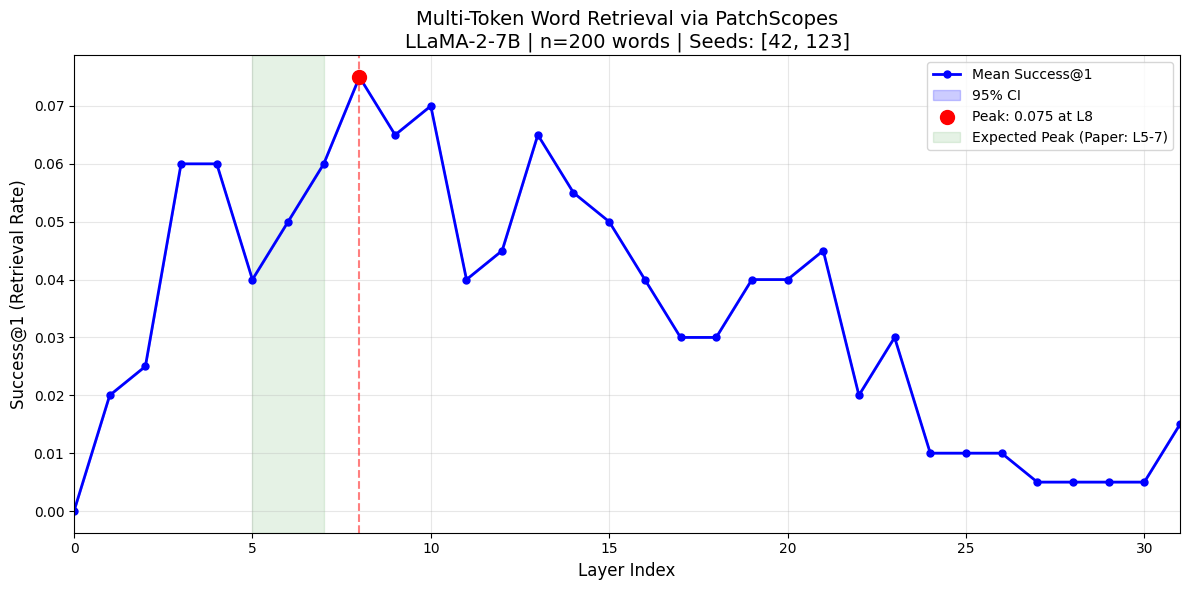

Saved: patchscopes_results/patchscopes_results.png


In [12]:
if 'stats_df' in dir() and stats_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    layers = stats_df['layer'].values
    means = stats_df['mean'].values
    cis = stats_df['ci_95'].values
    
    # Plot with confidence interval
    ax.plot(layers, means, 'b-o', linewidth=2, markersize=5, label='Mean Success@1')
    ax.fill_between(layers, means - cis, means + cis, alpha=0.2, color='blue', label='95% CI')
    
    # Mark peak
    ax.axvline(x=peak_layer, color='red', linestyle='--', alpha=0.5)
    ax.scatter([peak_layer], [peak_mean], color='red', s=100, zorder=5, 
               label=f'Peak: {peak_mean:.3f} at L{peak_layer}')
    
    # Expected region from paper
    ax.axvspan(5, 7, alpha=0.1, color='green', label='Expected Peak (Paper: L5-7)')
    
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Success@1 (Retrieval Rate)', fontsize=12)
    ax.set_title(f'Multi-Token Word Retrieval via PatchScopes\n'
                 f'LLaMA-2-7B | n={len(WORD_LIST)} words | Seeds: {SEEDS}', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max(layers))
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/patchscopes_results.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {OUTPUT_DIR}/patchscopes_results.png")